## Imports

<a href="https://colab.research.google.com/github/sylvainestebe/european-city-inference/blob/main/notebooks/tutorial_1_decision_making.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import jax
import matplotlib.pyplot as plt
import pandas as pd

from eci.environment import Environment
from eci.metrics import batch_compute_metrics
from eci.plots import plot_preference, plot_voting_metrics
from eci.voting_system.plurality import _vote_plurality , strategic_vote
from eci.voting_system.quadratic import _vote_quadratic, strategic_quadratic_vote
from eci.voting_system.random_voting import _vote_random

## Parameter Configuration 
The simulation constants are defined here.

In [2]:
NUM_VOTERS = 50  # Number of voters
NUM_CANDIDATES = 16  # Number of candidates
NUM_PREFERENCES = 3  # Number of preferences per voter
NUM_SIMULATIONS = 1000  # Number of simulation steps (trajectories)

## Environment Initialization 
The environment is created using the parameters defined above.

In [3]:
# Initialize environment
env = Environment(
    num_voters=NUM_VOTERS,  # Number of voters
    num_candidates=NUM_CANDIDATES,  # Number of candidates
    num_preferences=NUM_PREFERENCES,  # Number of preferences
)
env.num_simulations = NUM_SIMULATIONS  # Number of simulations
env._run_multi_agent_inference()

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_94044/3589628703.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


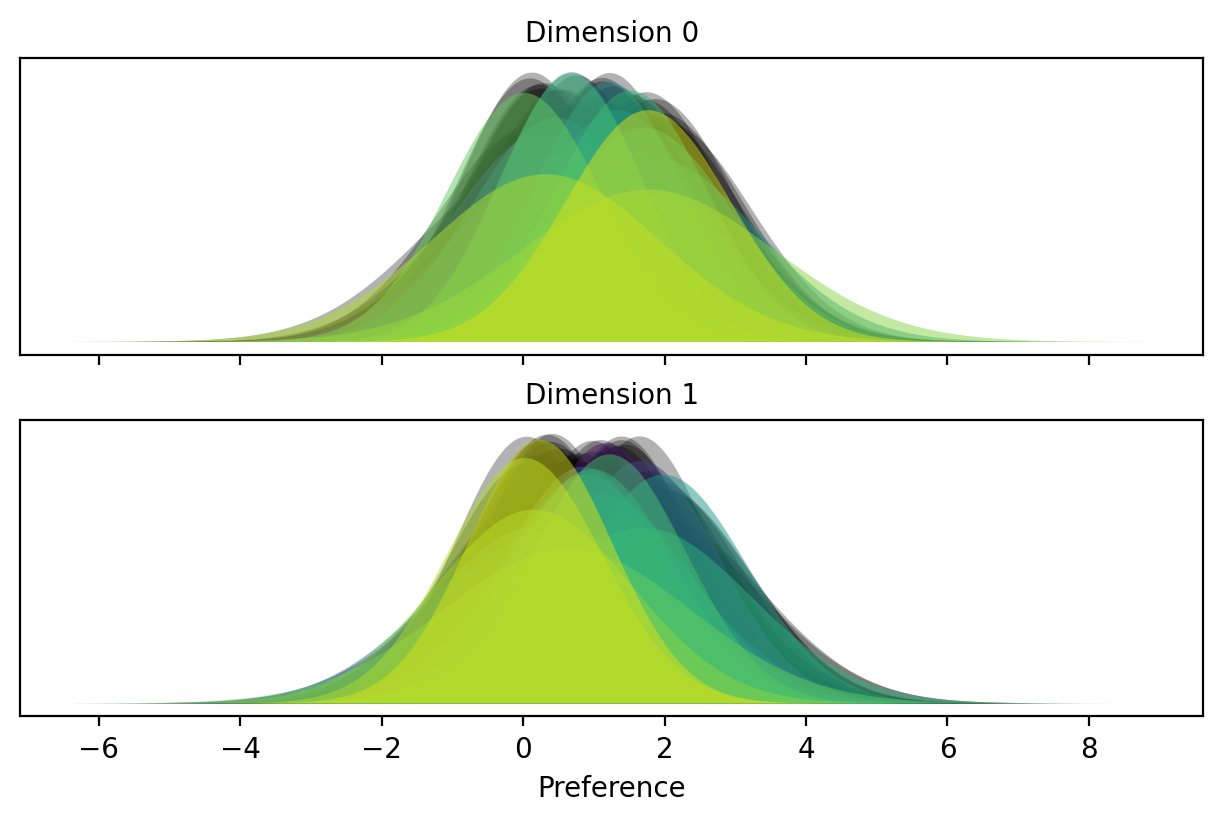

In [4]:
fig, ax = plot_preference(env)
fig.show()

## Voting systems
Now we will explore the different voting system implemented.

### Random Voting
In this one the agent make just random choice. It is a baseline.

In [5]:
# intiatialize random key
key = jax.random.PRNGKey(42)

# Run simulations
sim_rdm = env.run_n_simulation(_vote_random, key, NUM_SIMULATIONS)

# Compute metrics
metrics_rdm = batch_compute_metrics(sim_rdm)

### Plurality Voting
Then we have the plurality voting where agent vote for the candidate they prefer the most and the candidate with the maximum vote win. This is done in two round if there is no majority.

In [6]:
# intiatialize random key
key = jax.random.PRNGKey(42)

# Run simulations
sim_plurality = env.run_n_simulation(_vote_plurality, key, NUM_SIMULATIONS)
sim_plurality_strat = env.run_n_simulation(strategic_vote, key, NUM_SIMULATIONS)

# Compute metrics
metrics_plurality = batch_compute_metrics(sim_plurality)
metrics_plurality_strat = batch_compute_metrics(sim_plurality_strat)

### Quadratic Voting
Then the quadratic voting where agent have credits and should spend them on the candidates they prefer, they candidat with most of the vote win.

In [7]:
# Run perception
env._run_multi_agent_inference()

# intiatialize random key
key = jax.random.PRNGKey(42)

# Run simulations
sim_qv = env.run_n_simulation(_vote_quadratic, key, NUM_SIMULATIONS)
sim_qv_strat = env.run_n_simulation(strategic_quadratic_vote, key, NUM_SIMULATIONS)

# Compute metrics
metrics_qv = batch_compute_metrics(sim_plurality)
metrics_qv_strat = batch_compute_metrics(sim_qv_strat)

# Metrics
This section compares how different voting systems represent voter preferences and satisfaction. The **Winner Satisfaction** measures how well the winning candidate aligns with voters’ preferences:
and the **Vote Efficiency** evaluates how well votes reflect voters’ true preferences.

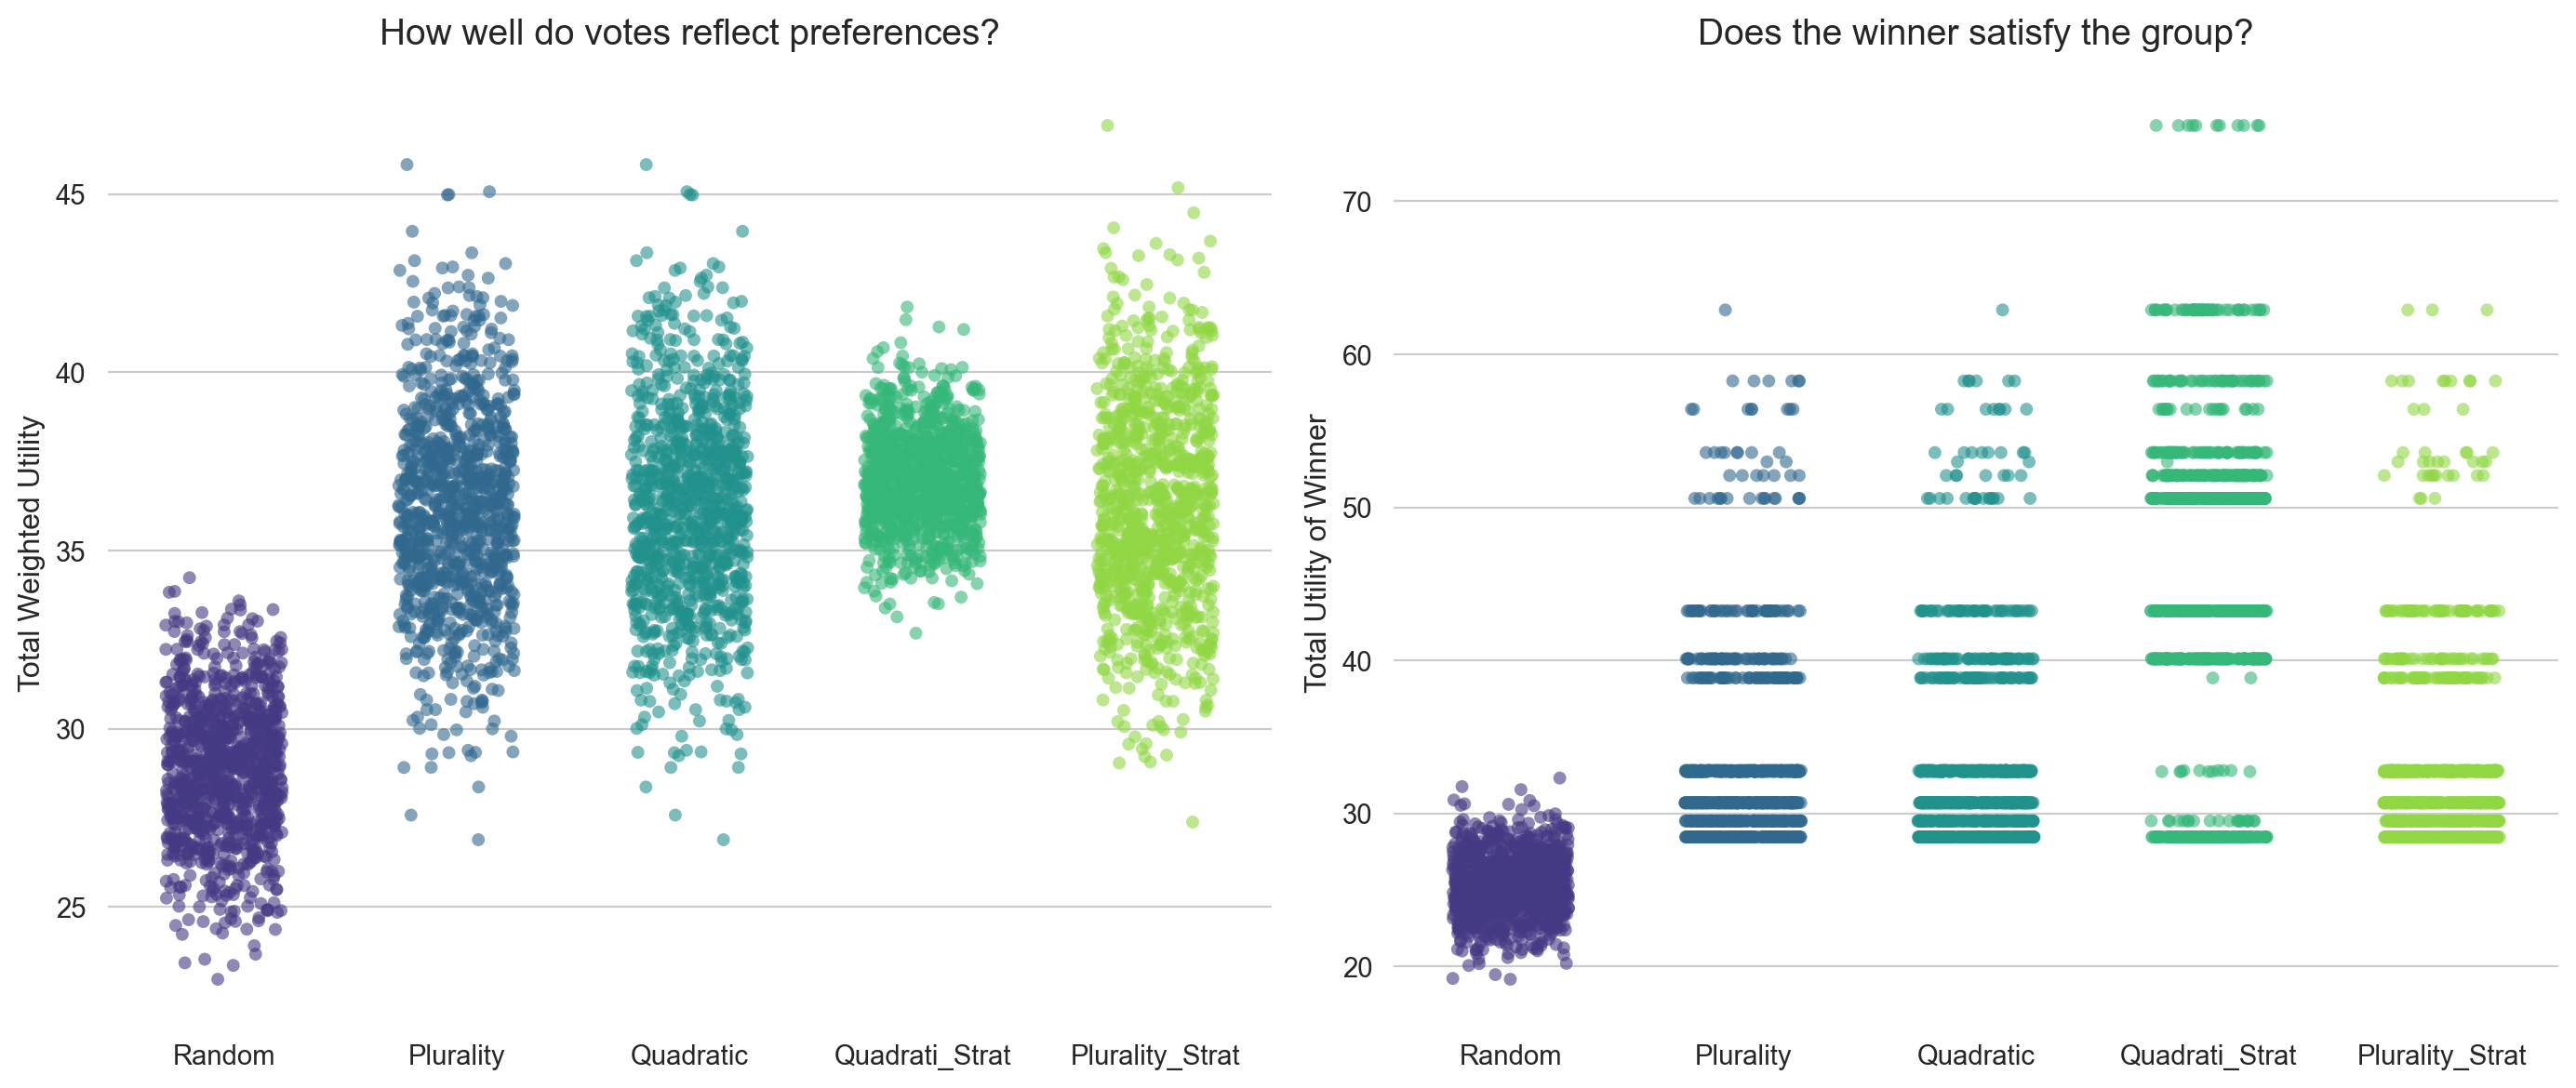

In [9]:
# change voting system labels
metrics_rdm["voting_system"] = "Random"
metrics_plurality["voting_system"] = "Plurality"
metrics_plurality_strat["voting_system"] = "Plurality_Strat"
metrics_qv["voting_system"] = "Quadratic"
metrics_qv_strat["voting_system"] = "Quadrati_Strat"

# combine dataframes
combined_df = pd.concat([metrics_rdm, metrics_plurality, metrics_qv,metrics_qv_strat,metrics_plurality_strat], ignore_index=True)

# plot voting metrics
fig = plot_voting_metrics(combined_df)
plt.show()